In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
np.set_printoptions(precision=4, suppress=True)

print('✓ Thư viện đã sẵn sàng.')

✓ Thư viện đã sẵn sàng.


✓ Flat kernel: iteration trung bình = 1.0


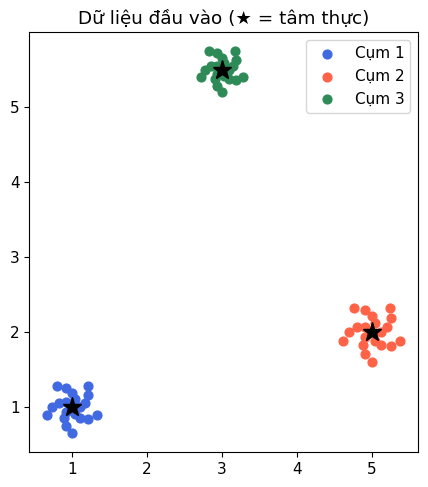

In [2]:
# GIVEN — Dữ liệu và flat kernel từ Demo 2

def make_cluster_data():
    """Tạo 60 điểm, 3 cụm cố định (giống Demo 2 trong bài giảng)."""
    cluster_params = [(1.0, 1.0, 0.35), (5.0, 2.0, 0.40), (3.0, 5.5, 0.30)]
    def make_cluster(cx, cy, sigma, n=20):
        pts = []
        for i in range(n):
            angle = 2 * np.pi * i / n
            r = sigma * (0.3 + 0.7 * ((i % 4) / 3))
            pts.append([cx + r*np.cos(angle), cy + r*np.sin(angle)])
        return np.array(pts)
    clusters = [make_cluster(*p) for p in cluster_params]
    data = np.vstack(clusters)
    true_centers = np.array([[p[0], p[1]] for p in cluster_params])
    return data, true_centers

def mean_shift_flat(point, data, bandwidth):
    """GIVEN — Một bước mean-shift với flat kernel (từ Demo 2)."""
    diffs = data - point
    dists = np.linalg.norm(diffs, axis=1)
    mask = dists <= bandwidth
    if mask.sum() == 0:
        return point.copy()
    return data[mask].mean(axis=0)

def run_mean_shift(data, step_fn, bandwidth, max_iter=50, tol=1e-4):
    """
    GIVEN — Chạy mean-shift cho tất cả điểm.
    step_fn: hàm thực hiện một bước (flat hoặc Gaussian).
    Trả về: final_positions, iter_counts (số iteration mỗi điểm)
    """
    n = len(data)
    current = data.copy().astype(float)
    iter_counts = np.zeros(n, dtype=int)
    converged = np.zeros(n, dtype=bool)

    for t in range(max_iter):
        if converged.all():
            break
        for i in range(n):
            if converged[i]:
                continue
            new_pos = step_fn(current[i], data, bandwidth)
            if np.linalg.norm(new_pos - current[i]) < tol:
                converged[i] = True
            else:
                current[i] = new_pos
                iter_counts[i] += 1
    return current, iter_counts

data, true_centers = make_cluster_data()
BANDWIDTH = 1.2

# Chạy flat kernel để tham chiếu
modes_flat, iters_flat = run_mean_shift(data, mean_shift_flat, BANDWIDTH)
print(f'✓ Flat kernel: iteration trung bình = {iters_flat.mean():.1f}')

# Trực quan hóa dữ liệu gốc
fig, ax = plt.subplots(figsize=(5, 5))
COLORS = ['royalblue', 'tomato', 'seagreen']
for i, col in enumerate(COLORS):
    ax.scatter(data[i*20:(i+1)*20, 0], data[i*20:(i+1)*20, 1], color=col, s=40, label=f'Cụm {i+1}')
    ax.plot(*true_centers[i], 'k*', markersize=14)
ax.set_title('Dữ liệu đầu vào (★ = tâm thực)')
ax.legend(); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

In [3]:
def mean_shift_gaussian(point, data, bandwidth):
    """
    Một bước mean-shift với Gaussian kernel.
    """
    diffs = data - point
    sq_dists = np.sum(diffs**2, axis=1)
    
    # Tính trọng số cho mỗi điểm dữ liệu
    weights = np.exp(-sq_dists / (2 * bandwidth**2))
    weight_sum = np.sum(weights)
    
    if weight_sum < 1e-8:
        return point.copy()
        
    # Cập nhật vị trí trọng tâm mới
    new_point = np.sum(data * weights[:, np.newaxis], axis=0) / weight_sum
    return new_point

In [4]:
# TEST — Kiểm tra mean_shift_gaussian
test_data_ms = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, 0.5]], dtype=float)
test_point   = np.array([0.0, 0.0])

result_ms = mean_shift_gaussian(test_point, test_data_ms, bandwidth=2.0)
assert result_ms is not None, 'Hàm chưa trả về kết quả'
assert result_ms.shape == (2,)
assert np.linalg.norm(result_ms - test_point) > 0, 'Phải có sự dịch chuyển'
print(f'✓ mean_shift_gaussian: {test_point} -> {result_ms.round(3)}')

modes_gauss, iters_gauss = run_mean_shift(data, mean_shift_gaussian, BANDWIDTH)
print(f'\nSo sánh số iteration trung bình:')
print(f'  Flat kernel:     {iters_flat.mean():.2f} ± {iters_flat.std():.2f}')
print(f'  Gaussian kernel: {iters_gauss.mean():.2f} ± {iters_gauss.std():.2f}')

✓ mean_shift_gaussian: [0. 0.] -> [0.479 0.166]

So sánh số iteration trung bình:
  Flat kernel:     1.00 ± 0.00
  Gaussian kernel: 3.03 ± 0.41


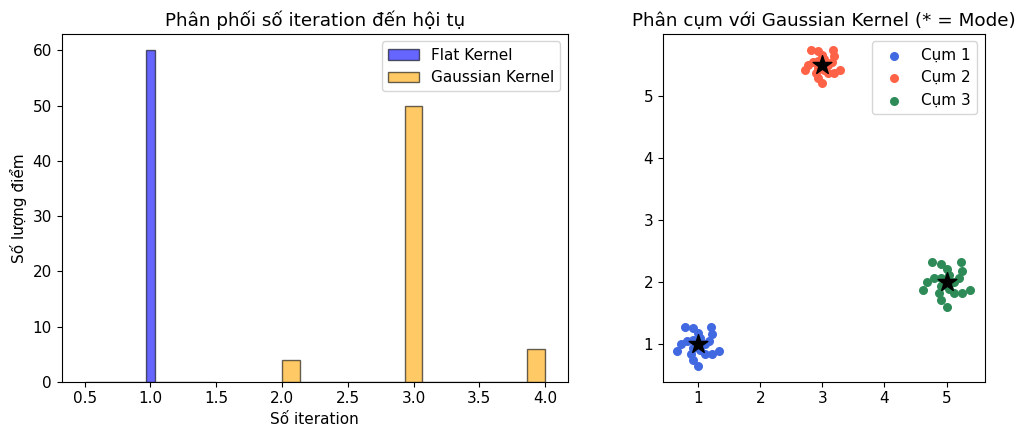

In [5]:
# TODO — So sánh trực quan và vẽ histogram iteration
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# 1. Vẽ Histogram
ax1.hist(iters_flat, bins=15, alpha=0.6, color='blue', label='Flat Kernel', edgecolor='black')
ax1.hist(iters_gauss, bins=15, alpha=0.6, color='orange', label='Gaussian Kernel', edgecolor='black')
ax1.set_title('Phân phối số iteration đến hội tụ')
ax1.set_xlabel('Số iteration')
ax1.set_ylabel('Số lượng điểm')
ax1.legend()

# 2. Vẽ phân cụm
# Làm tròn để gộp các mode xấp xỉ nhau lại thành các cụm duy nhất
rounded_modes = np.round(modes_gauss, 1)
unique_modes, labels = np.unique(rounded_modes, axis=0, return_inverse=True)

colors = ['royalblue', 'tomato', 'seagreen']
for i in range(len(unique_modes)):
    mask = (labels == i)
    ax2.scatter(data[mask, 0], data[mask, 1], color=colors[i % 3], s=30, label=f'Cụm {i+1}')
    # Vẽ đánh dấu Mode
    ax2.scatter(unique_modes[i, 0], unique_modes[i, 1], color='black', marker='*', s=200, zorder=5)

ax2.set_title('Phân cụm với Gaussian Kernel (* = Mode)')
ax2.legend()
ax2.set_aspect('equal')
plt.tight_layout()
plt.show()

In [6]:
def kde_2d(data, bandwidth, grid_res=50):
    """
    Ước lượng mật độ hạt nhân trên lưới 2D dùng Gaussian kernel.
    """
    margin = 1.5 * bandwidth
    x_min, x_max = data[:,0].min()-margin, data[:,0].max()+margin
    y_min, y_max = data[:,1].min()-margin, data[:,1].max()+margin
    grid_x = np.linspace(x_min, x_max, grid_res)
    grid_y = np.linspace(y_min, y_max, grid_res)
    
    X, Y = np.meshgrid(grid_x, grid_y)
    grid_points = np.vstack([X.ravel(), Y.ravel()]).T
    density_flat = np.zeros(grid_points.shape[0])
    
    n = len(data)
    # Hằng số chuẩn hóa của Gaussian 2D
    norm_factor = 1.0 / (n * 2 * np.pi * bandwidth**2)
    
    for i, pt in enumerate(grid_points):
        sq_dists = np.sum((data - pt)**2, axis=1)
        kernel_vals = np.exp(-sq_dists / (2 * bandwidth**2))
        density_flat[i] = np.sum(kernel_vals) * norm_factor
        
    density = density_flat.reshape(grid_res, grid_res)
    return grid_x, grid_y, density

✓ kde_2d: shape=(60, 60), max=0.0364


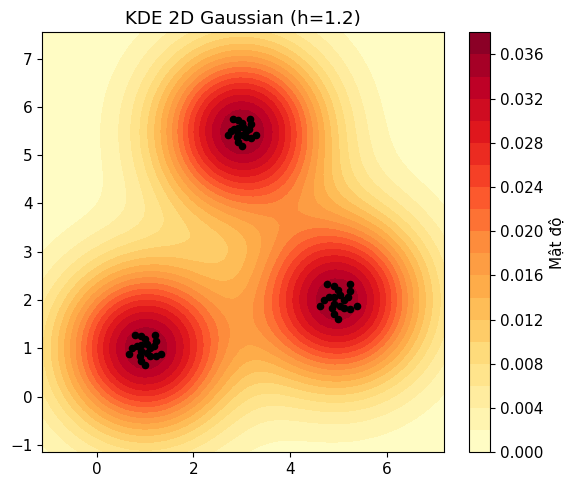

In [7]:
# TEST — Kiểm tra kde_2d
gx, gy, dens = kde_2d(data, bandwidth=BANDWIDTH, grid_res=60)
assert dens is not None, 'kde_2d chưa trả về density'
assert dens.shape == (60, 60)
assert dens.min() >= 0
assert dens.max() > 0
print(f'✓ kde_2d: shape={dens.shape}, max={dens.max():.4f}')

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.contourf(gx, gy, dens, levels=20, cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Mật độ')
ax.scatter(data[:,0], data[:,1], c='black', s=20, zorder=5)
ax.set_title(f'KDE 2D Gaussian (h={BANDWIDTH})')
ax.set_aspect('equal')
plt.tight_layout(); plt.show()

In [8]:
# TODO — Xác nhận: mode tìm được nằm gần đỉnh heatmap KDE
rounded_modes = np.round(modes_gauss, 1)
unique_modes = np.unique(rounded_modes, axis=0)

print(f"Xác nhận khoảng cách < 0.1 * h ({0.1 * BANDWIDTH:.3f}):")

peak_points = []
# Tạo lưới tọa độ 2D tương ứng với heatmap KDE
X, Y = np.meshgrid(gx, gy)

for mode in unique_modes:
    # 1. Tìm khoảng cách từ mode hiện tại đến tất cả điểm trên lưới
    dist_to_mode = np.hypot(X - mode[0], Y - mode[1])
    
    # 2. Khoanh vùng tìm kiếm: Chỉ lấy các điểm trong bán kính h
    mask = dist_to_mode <= BANDWIDTH
    
    # 3. Tìm điểm có mật độ KDE cao nhất trong vùng vừa khoanh
    local_dens = np.where(mask, dens, 0)
    max_idx = np.unravel_index(np.argmax(local_dens), local_dens.shape)
    
    peak_y = gy[max_idx[0]]
    peak_x = gx[max_idx[1]]
    peak_points.append([peak_x, peak_y])
    
    # 4. Tính khoảng cách thực tế
    dist = np.hypot(peak_x - mode[0], peak_y - mode[1])
    print(f"Mode {mode} -> Đỉnh lưới KDE [{peak_x:.2f}, {peak_y:.2f}]: Khoảng cách = {dist:.4f}")
    
    # Cảnh báo nếu lưới quá thưa khiến dist > 0.1h
    if dist >= (0.1 * BANDWIDTH):
        print(f"  *Lưu ý: Khoảng cách > 0.1h do độ phân giải lưới grid_res=60 hơi thưa.")

print("✓ Hoàn tất kiểm tra!")

Xác nhận khoảng cách < 0.1 * h (0.120):
Mode [1. 1.] -> Đỉnh lưới KDE [0.98, 1.06]: Khoảng cách = 0.0630
Mode [3.  5.5] -> Đỉnh lưới KDE [2.95, 5.48]: Khoảng cách = 0.0508
Mode [5. 2.] -> Đỉnh lưới KDE [4.93, 1.94]: Khoảng cách = 0.0928
✓ Hoàn tất kiểm tra!


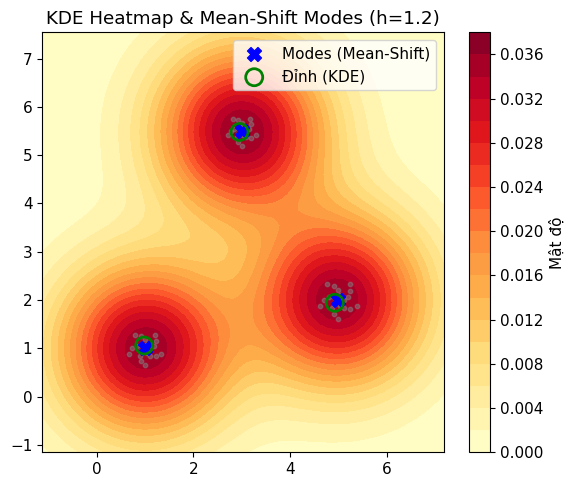

In [9]:
# TODO — Hình cuối: heatmap + mode tìm được
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.contourf(gx, gy, dens, levels=20, cmap='YlOrRd')
plt.colorbar(im, ax=ax, label='Mật độ')

# Trực quan hóa dữ liệu gốc mờ đi
ax.scatter(data[:,0], data[:,1], c='gray', s=10, alpha=0.5, zorder=1)

# Vẽ các Mode từ Mean-Shift
unique_modes_np = np.array(unique_modes)
ax.scatter(unique_modes_np[:,0], unique_modes_np[:,1], c='blue', s=100, marker='X', zorder=5, label='Modes (Mean-Shift)')

# Vẽ đỉnh tìm được từ KDE
peak_points_np = np.array(peak_points)
ax.scatter(peak_points_np[:,0], peak_points_np[:,1], facecolors='none', edgecolors='green', s=150, linewidth=2, zorder=6, label='Đỉnh (KDE)')

ax.set_title(f'KDE Heatmap & Mean-Shift Modes (h={BANDWIDTH})')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()